<a href="https://colab.research.google.com/github/LeinMS/hse-image-captioning/blob/BLIP/BLIP_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image
from transformers import AutoModelForVision2Seq, AutoProcessor
import time, requests, torch

In [2]:
#GET WEGHTS FROM MY GOOGLE.DRIVE
try:
    import gdown
except ImportError:
    %pip install gdown -q
file_id = "1cm8ZqDM73lN9N6WmM96ssiVMN8_shcUm"
output_filename = "Flickr30k_1.zip"

print(f"Downloading file with ID {output_filename}...")
# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

print(f"Unzipping {output_filename}...")
# Unzip the downloaded file
!unzip -o -q {output_filename}
print("Download and unzipping complete.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1cm8ZqDM73lN9N6WmM96ssiVMN8_shcUm
From (redirected): https://drive.google.com/uc?id=1cm8ZqDM73lN9N6WmM96ssiVMN8_shcUm&confirm=t&uuid=fcb8587f-66fd-4526-9d4b-80bc4f9b453e
To: /content/Flickr30k_1.zip
100% 40.5M/40.5M [00:00<00:00, 65.1MB/s]
Unzipping Flickr30k_1.zip...
Download and unzipping complete.


In [3]:
#DEFINE MODEL
model_id = "Salesforce/blip-image-captioning-base"
processor = AutoProcessor.from_pretrained(model_id, torch_dtype=torch.float16)
model = AutoModelForVision2Seq.from_pretrained(model_id)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

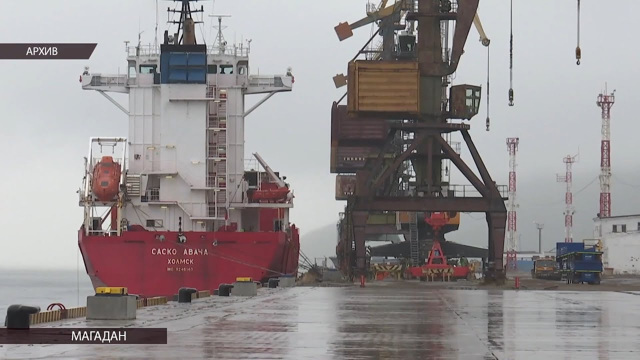

Inference time: 3.51
['a large ship is docked at the dock']


In [13]:
#INFERENCE OF ORIGINAL MODEL
img_url = 'https://i.ytimg.com/vi/mbdHmQO-DB0/maxresdefault.jpg'
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

time_start = time.time()
processed = processor(images=image, padding="max_length", return_tensors="pt")
generated_output = model.generate(pixel_values=processed['pixel_values'], max_new_tokens=64)


x, y = image.size
scale = 1 if ((x <= 500) & (y <= 500)) else (x // 500 if x > y else y // 500)
display(image.resize((x//scale, y//scale)))

print(f'Inference time: {time.time() - time_start:.2f}')
print(processor.batch_decode(generated_output, skip_special_tokens=True))


In [8]:
#DEFINE FINETUNED MODEL
tuned_model = AutoModelForVision2Seq.from_pretrained('/content/Flickr30k_1')

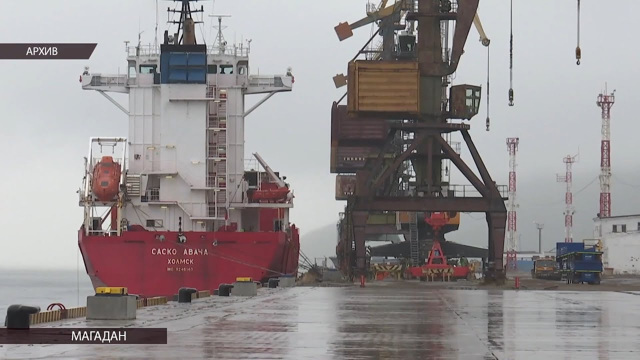

Inference time: 4.69
['a red boat is docked in a harbor with a crane in the background']


In [14]:
#INFERENCE OF FINETUNED MODEL
time_start = time.time()
processed = processor(images=image, padding="max_length", return_tensors="pt")
generated_output = tuned_model.generate(pixel_values=processed['pixel_values'], max_new_tokens=64)


x, y = image.size
scale = 1 if ((x <= 500) & (y <= 500)) else (x // 500 if x > y else y // 500)
display(image.resize((x//scale, y//scale)))

print(f'Inference time: {time.time() - time_start:.2f}')
print(processor.batch_decode(generated_output, skip_special_tokens=True))